In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import time as timer

pd.set_option("display.max_columns", 40)
os.makedirs("figures/model/classification", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
os.makedirs("./models", exist_ok=True)
warnings.filterwarnings("ignore", category=UserWarning)
%matplotlib inline

In [3]:
station_day_df = pd.read_parquet("./data/processed/road_station_day_dataset.parquet")
station_day_df["planned_date"] = pd.to_datetime(station_day_df["planned_date"])

print(f"Loaded: {len(station_day_df):,} station-day rows")
print(f"Unique stations: {station_day_df['station_name'].nunique():,}")
print(f"Date range: {station_day_df['planned_date'].min().date()} — {station_day_df['planned_date'].max().date()}")
print(f"Columns: {list(station_day_df.columns)}")

Loaded: 33,941 station-day rows
Unique stations: 2,506
Date range: 2026-04-03 — 2026-04-28
Columns: ['station_name', 'stanox', 'planned_date', 'train_movements', 'mean_delay_minutes', 'median_delay_minutes', 'late_movements', 'mean_late_minutes', 'max_late_minutes', 'early_movements', 'mean_early_minutes', 'delayed_movements_5min', 'severe_delay_movements_15min', 'late_share', 'early_share', 'delayed_share_5min', 'severe_delay_share_15min', 'road_closure_count', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'n_unplanned_closures', 'has_road_closure', 'movements_during_closure', 'mean_delay_during_closure', 'pct_late_during_closure', 'max_delay_during_closure', 'pct_delayed_5min_during', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d']


In [4]:
# max_effective_duration_hours showed extreme values (max 456h = 19 days)
# in eda_06_01. Cap at 99th percentile of training data to prevent
# a handful of multi-week closures from dominating tree splits.
# Same cap applied to timetable dataset at inference time.

P99_DURATION = station_day_df["max_effective_duration_hours"].quantile(0.99)
station_day_df["max_effective_duration_hours"] = station_day_df[
    "max_effective_duration_hours"
].clip(upper=P99_DURATION)
station_day_df["mean_effective_duration_hours"] = station_day_df[
    "mean_effective_duration_hours"
].clip(upper=P99_DURATION)

print(f"Duration capped at 99th percentile: {P99_DURATION:.1f} hours ({P99_DURATION/24:.1f} days)")
print(station_day_df["max_effective_duration_hours"].describe().round(2))

Duration capped at 99th percentile: 456.0 hours (19.0 days)
count    33941.00
mean       128.62
std        202.29
min          0.00
25%          0.00
50%          0.25
75%        456.00
max        456.00
Name: max_effective_duration_hours, dtype: float64


##  Define Binary Target

Threshold: mean delay > 5 min
Not disrupted (0): 32,025
Disrupted     (1): 1,916
Disruption rate:   5.65%
Class imbalance ratio (neg/pos): 16.7:1


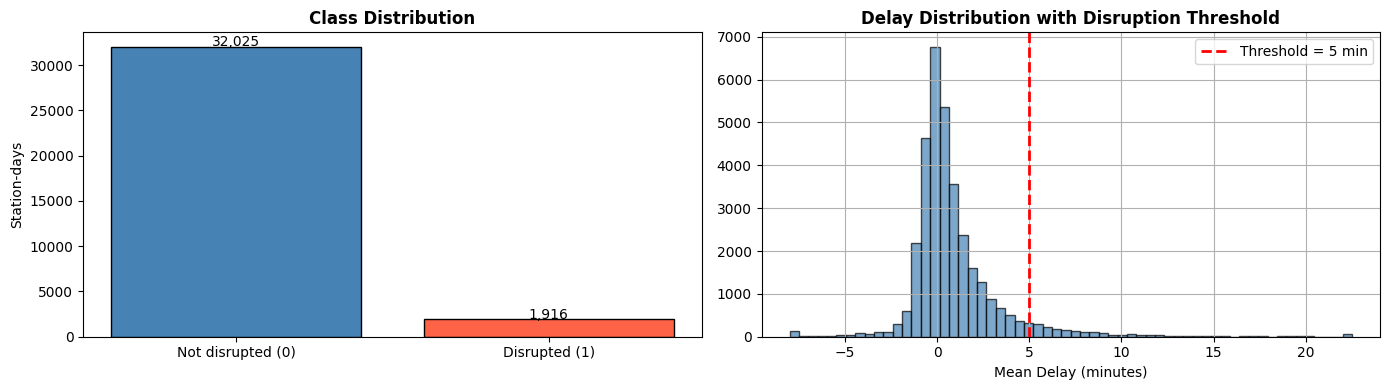

In [5]:
DISRUPTION_THRESHOLD = 5  # minutes — mean station-day delay

station_day_df["disrupted"] = (
    station_day_df["mean_delay_minutes"] > DISRUPTION_THRESHOLD
).astype(int)

counts = station_day_df["disrupted"].value_counts()
rate   = station_day_df["disrupted"].mean()

print(f"Threshold: mean delay > {DISRUPTION_THRESHOLD} min")
print(f"Not disrupted (0): {counts.get(0, 0):,}")
print(f"Disrupted     (1): {counts.get(1, 0):,}")
print(f"Disruption rate:   {rate:.2%}")
print(f"Class imbalance ratio (neg/pos): {counts.get(0,0)/counts.get(1,1):.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    ["Not disrupted (0)", "Disrupted (1)"],
    [counts.get(0,0), counts.get(1,0)],
    color=["steelblue", "tomato"], edgecolor="black"
)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Station-days")
for i, v in enumerate([counts.get(0,0), counts.get(1,0)]):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10)

station_day_df["mean_delay_minutes"].hist(
    bins=60, ax=axes[1], edgecolor="black", alpha=0.7, color="steelblue"
)
axes[1].axvline(DISRUPTION_THRESHOLD, color="red", linestyle="--", lw=2,
                label=f"Threshold = {DISRUPTION_THRESHOLD} min")
axes[1].set_xlabel("Mean Delay (minutes)")
axes[1].set_title("Delay Distribution with Disruption Threshold", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/model/classification/class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

Disruption rate by day of week:
     disruption_rate  n_days
Mon            0.057    6322
Tue            0.037    6029
Wed            0.038    1976
Thu            0.047    4276
Fri            0.086    6070
Sat            0.069    3639
Sun            0.051    5629


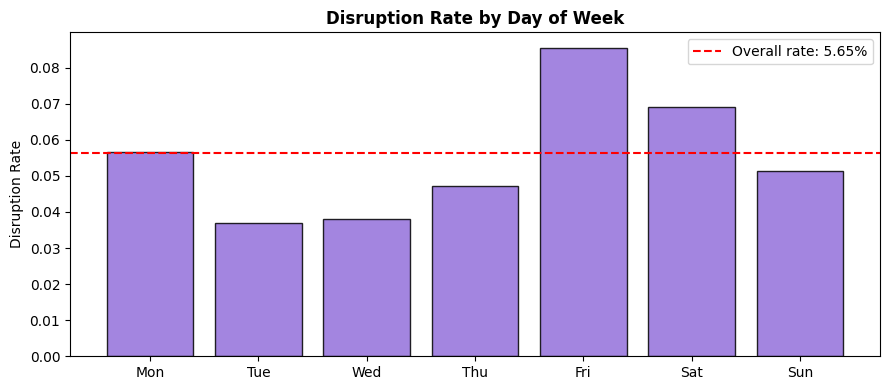

In [6]:
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

dow_stats = (
    station_day_df.groupby("day_of_week")["disrupted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "disruption_rate", "count": "n_days"})
)
dow_stats.index = [DOW_MAP[i] for i in dow_stats.index]

print("Disruption rate by day of week:")
print(dow_stats.round(3))

plt.figure(figsize=(9, 4))
plt.bar(dow_stats.index, dow_stats["disruption_rate"],
        color="mediumpurple", edgecolor="black", alpha=0.85)
plt.axhline(rate, color="red", linestyle="--", lw=1.5,
            label=f"Overall rate: {rate:.2%}")
plt.ylabel("Disruption Rate")
plt.title("Disruption Rate by Day of Week", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("figures/model/classification/disruption_by_dow.png", dpi=200, bbox_inches="tight")
plt.show()

## Feature Set Definition

In [7]:
# Full feature set — includes new features from eda_05_01 rewrite
# total_closure_severity, max_road_class, lag features added
# Must match exactly what is present in both training and timetable datasets

BASE_FEATURES = [
    # Closure presence and severity
    "has_road_closure",
    "road_closure_count",
    "n_unplanned_closures",
    "min_distance_km",
    "mean_distance_km",
    "max_effective_duration_hours",
    "mean_effective_duration_hours",
    "inv_distance_sum",
    "total_closure_severity",
    "max_road_class",
    # Lag features — temporal memory of road pressure
    "closures_lag1d",
    "closures_lag3d",
    "closures_lag7d",
    # Temporal context
    "day_of_week",
    "is_weekend",
    "is_monday",
    "is_friday",
    # Service volume
    "train_movements",
]

features = [f for f in BASE_FEATURES if f in station_day_df.columns]
missing  = [f for f in BASE_FEATURES if f not in station_day_df.columns]

if missing:
    print(f"WARNING — features missing from training data (re-run eda_05_01): {missing}")
else:
    print(f"All {len(features)} features present in training data.")

print(f"\nFeatures used: {features}")

All 18 features present in training data.

Features used: ['has_road_closure', 'road_closure_count', 'n_unplanned_closures', 'min_distance_km', 'mean_distance_km', 'max_effective_duration_hours', 'mean_effective_duration_hours', 'inv_distance_sum', 'total_closure_severity', 'max_road_class', 'closures_lag1d', 'closures_lag3d', 'closures_lag7d', 'day_of_week', 'is_weekend', 'is_monday', 'is_friday', 'train_movements']


## Temporal Train/Test Split

In [8]:
TARGET = "disrupted"

df_model = (
    station_day_df[features + [TARGET, "planned_date"]]
    .dropna(subset=features)
    .sort_values("planned_date")
    .reset_index(drop=True)
)

# Temporal split — not random
# Prevents future closure information leaking into training via lag features
split_idx = int(len(df_model) * 0.8)
train_df  = df_model.iloc[:split_idx]
test_df   = df_model.iloc[split_idx:]

X_train = train_df[features]
X_test  = test_df[features]
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

print(f"Train: {len(X_train):,} rows | {train_df['planned_date'].min().date()} — {train_df['planned_date'].max().date()}")
print(f"  Disruption rate: {y_train.mean():.2%}")
print()
print(f"Test:  {len(X_test):,} rows  | {test_df['planned_date'].min().date()} — {test_df['planned_date'].max().date()}")
print(f"  Disruption rate: {y_test.mean():.2%}")

Train: 27,152 rows | 2026-04-03 — 2026-04-25
  Disruption rate: 5.89%

Test:  6,789 rows  | 2026-04-25 — 2026-04-28
  Disruption rate: 4.65%


In [9]:
from sklearn.dummy          import DummyClassifier
from sklearn.linear_model   import LogisticRegression
from sklearn.ensemble       import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline       import Pipeline
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import (
    f1_score, average_precision_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve,
)
from xgboost import XGBClassifier

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos if pos > 0 else 1.0
print(f"Train class ratio (neg/pos): {spw:.1f}:1 — used as scale_pos_weight for XGBoost")

models = {
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent", random_state=42),
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=42
        )),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        subsample=0.8, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        objective="binary:logistic", eval_metric="aucpr",
        random_state=42, verbosity=0,
    ),
}

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        class_weight="balanced", random_state=42, verbose=-1,
    )
    print("LightGBM available — included.")
except ImportError:
    print("LightGBM not installed — skipped.")

print(f"\nModels to evaluate: {list(models.keys())}")

Train class ratio (neg/pos): 16.0:1 — used as scale_pos_weight for XGBoost
LightGBM available — included.

Models to evaluate: ['Dummy (baseline)', 'LogisticRegression', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


## Train and Evaluate All Models

In [10]:
results = []

for name, model_obj in models.items():
    t0 = timer.time()
    model_obj.fit(X_train, y_train)
    elapsed = timer.time() - t0

    y_pred  = model_obj.predict(X_test)
    y_proba = (
        model_obj.predict_proba(X_test)[:, 1]
        if hasattr(model_obj, "predict_proba")
        else y_pred.astype(float)
    )

    results.append({
        "model":     name,
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "PR_AUC":    average_precision_score(y_test, y_proba),
        "ROC_AUC":   roc_auc_score(y_test, y_proba),
        "train_sec": round(elapsed, 2),
        "_model":    model_obj,
        "_y_pred":   y_pred,
        "_y_proba":  y_proba,
    })
    print(f"{name:<22} F1={results[-1]['F1']:.3f}  "
          f"PR-AUC={results[-1]['PR_AUC']:.3f}  "
          f"ROC-AUC={results[-1]['ROC_AUC']:.3f}  ({elapsed:.1f}s)")

results_df = (
    pd.DataFrame(results)
    .sort_values("PR_AUC", ascending=False)
    .reset_index(drop=True)
)

print()
print("=== Model Comparison Table ===")
display(results_df[["model", "F1", "PR_AUC", "ROC_AUC", "train_sec"]])

# Baseline PR-AUC for reference
baseline_prauc = y_test.mean()
print(f"\nRandom baseline PR-AUC (disruption rate): {baseline_prauc:.3f}")
print(f"Best model uplift over baseline: +{results_df.iloc[0]['PR_AUC'] - baseline_prauc:.3f}")

Dummy (baseline)       F1=0.000  PR-AUC=0.047  ROC-AUC=0.500  (0.0s)
LogisticRegression     F1=0.130  PR-AUC=0.077  ROC-AUC=0.649  (0.1s)
RandomForest           F1=0.059  PR-AUC=0.072  ROC-AUC=0.639  (0.7s)
GradientBoosting       F1=0.000  PR-AUC=0.076  ROC-AUC=0.679  (10.7s)
XGBoost                F1=0.154  PR-AUC=0.085  ROC-AUC=0.681  (1.7s)
LightGBM               F1=0.154  PR-AUC=0.080  ROC-AUC=0.672  (2.5s)

=== Model Comparison Table ===


,model,F1,PR_AUC,ROC_AUC,train_sec
0,XGBoost,0.154270,0.085358,0.680648,1.70
1,LightGBM,0.153511,0.079955,0.672239,2.53
2,LogisticRegression,0.130154,0.077279,0.649104,0.07
3,GradientBoosting,0.000000,0.076248,0.678743,10.72
4,RandomForest,0.058989,0.072133,0.639414,0.71
5,Dummy (baseline),0.000000,0.046546,0.500000,0.00



Random baseline PR-AUC (disruption rate): 0.047
Best model uplift over baseline: +0.039


## Model Comparision Plots

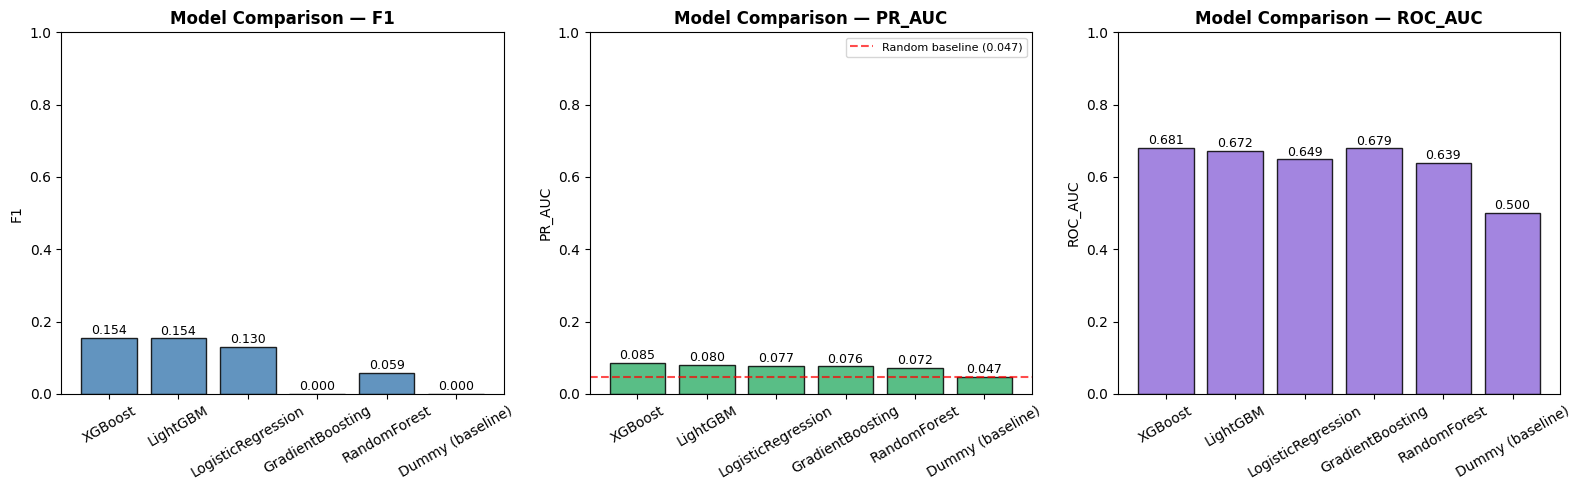

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, color in [
    (axes[0], "F1",      "steelblue"),
    (axes[1], "PR_AUC",  "mediumseagreen"),
    (axes[2], "ROC_AUC", "mediumpurple"),
]:
    ax.bar(results_df["model"], results_df[metric],
           color=color, edgecolor="black", alpha=0.85)
    ax.set_title(f"Model Comparison — {metric}", fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylim(0, 1)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

    # Baseline reference line on PR-AUC plot
    if metric == "PR_AUC":
        ax.axhline(y_test.mean(), color="red", linestyle="--",
                   alpha=0.7, label=f"Random baseline ({y_test.mean():.3f})")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/model/classification/model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

### Precision-Recall Curves

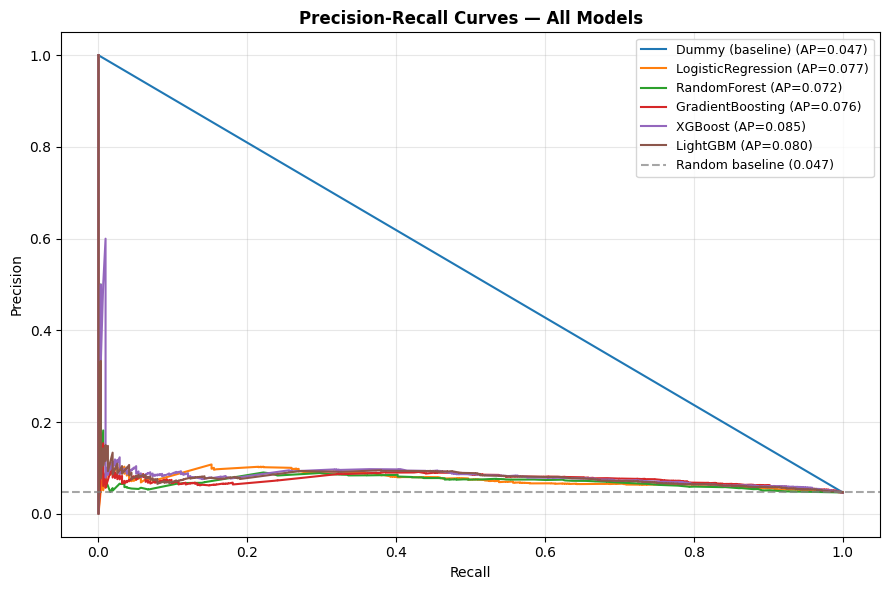

In [12]:
plt.figure(figsize=(9, 6))
for row in results:
    p, r, _ = precision_recall_curve(y_test, row["_y_proba"])
    plt.plot(r, p, lw=1.5, label=f"{row['model']} (AP={row['PR_AUC']:.3f})")

plt.axhline(y_test.mean(), color="grey", linestyle="--", alpha=0.7,
            label=f"Random baseline ({y_test.mean():.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models", fontweight="bold")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/model/classification/precision_recall_curves.png", dpi=200, bbox_inches="tight")
plt.show()

### Confusion Matrices (Top 2 Models)


XGBoost:
               precision    recall  f1-score   support

Not disrupted       0.97      0.79      0.87      6473
    Disrupted       0.09      0.44      0.15       316

     accuracy                           0.77      6789
    macro avg       0.53      0.62      0.51      6789
 weighted avg       0.93      0.77      0.84      6789


LightGBM:
               precision    recall  f1-score   support

Not disrupted       0.97      0.79      0.87      6473
    Disrupted       0.09      0.45      0.15       316

     accuracy                           0.77      6789
    macro avg       0.53      0.62      0.51      6789
 weighted avg       0.93      0.77      0.83      6789



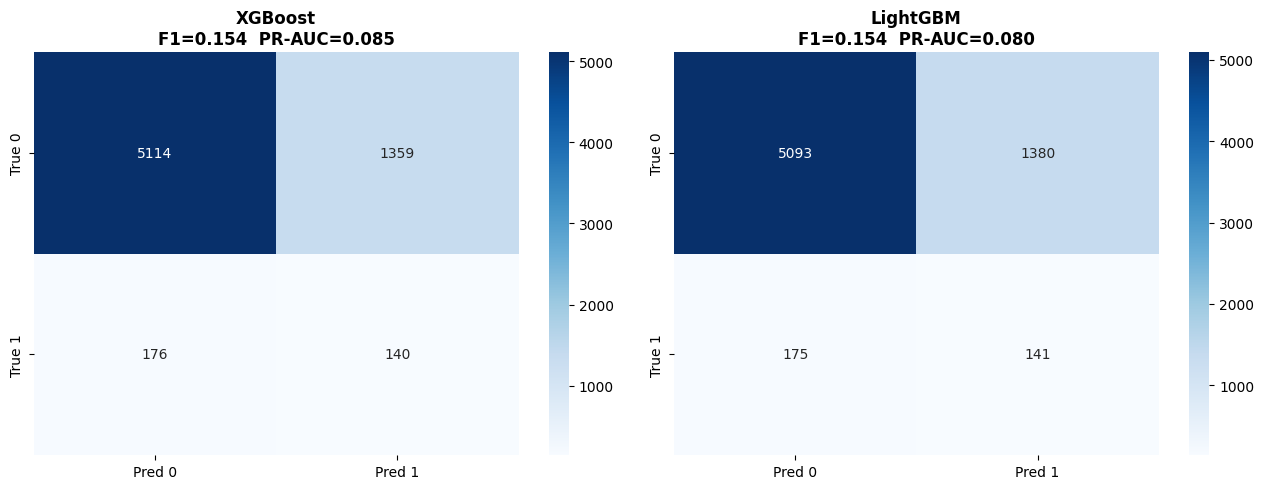

In [13]:
# Exclude Dummy from top 2 — it is a baseline not a real model
real_results = [r for r in results if r["model"] != "Dummy (baseline)"]
top2 = sorted(real_results, key=lambda r: r["PR_AUC"], reverse=True)[:2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, row in zip(axes, top2):
    cm = confusion_matrix(y_test, row["_y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"])
    ax.set_title(
        f"{row['model']}\nF1={row['F1']:.3f}  PR-AUC={row['PR_AUC']:.3f}",
        fontweight="bold"
    )
    print(f"\n{row['model']}:")
    print(classification_report(
        y_test, row["_y_pred"],
        target_names=["Not disrupted", "Disrupted"],
        zero_division=0
    ))

plt.tight_layout()
plt.savefig("figures/model/classification/confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()

Best model: XGBoost  (PR-AUC=0.085, F1=0.154)


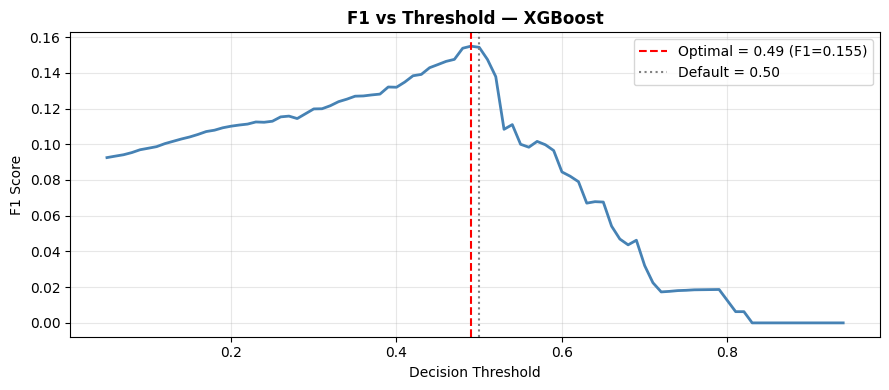


Optimal threshold: 0.49  →  F1 = 0.155

               precision    recall  f1-score   support

Not disrupted       0.97      0.78      0.87      6473
    Disrupted       0.09      0.46      0.15       316

     accuracy                           0.77      6789
    macro avg       0.53      0.62      0.51      6789
 weighted avg       0.93      0.77      0.83      6789



In [14]:
# Best real model by PR-AUC
best_row   = sorted(real_results, key=lambda r: r["PR_AUC"], reverse=True)[0]
best_model = best_row["_model"]
best_name  = best_row["model"]
best_proba = best_row["_y_proba"]

print(f"Best model: {best_name}  (PR-AUC={best_row['PR_AUC']:.3f}, F1={best_row['F1']:.3f})")

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [
    f1_score(y_test, (best_proba >= t).astype(int), zero_division=0)
    for t in thresholds
]

opt_idx = np.argmax(f1_scores)
opt_t   = thresholds[opt_idx]
opt_f1  = f1_scores[opt_idx]

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, lw=2, color="steelblue")
plt.axvline(opt_t,  color="red",  linestyle="--",
            label=f"Optimal = {opt_t:.2f} (F1={opt_f1:.3f})")
plt.axvline(0.5,    color="grey", linestyle=":",
            label="Default = 0.50")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score")
plt.title(f"F1 vs Threshold — {best_name}", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/model/classification/threshold_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\nOptimal threshold: {opt_t:.2f}  →  F1 = {opt_f1:.3f}")
print()
print(classification_report(
    y_test, (best_proba >= opt_t).astype(int),
    target_names=["Not disrupted", "Disrupted"],
    zero_division=0
))

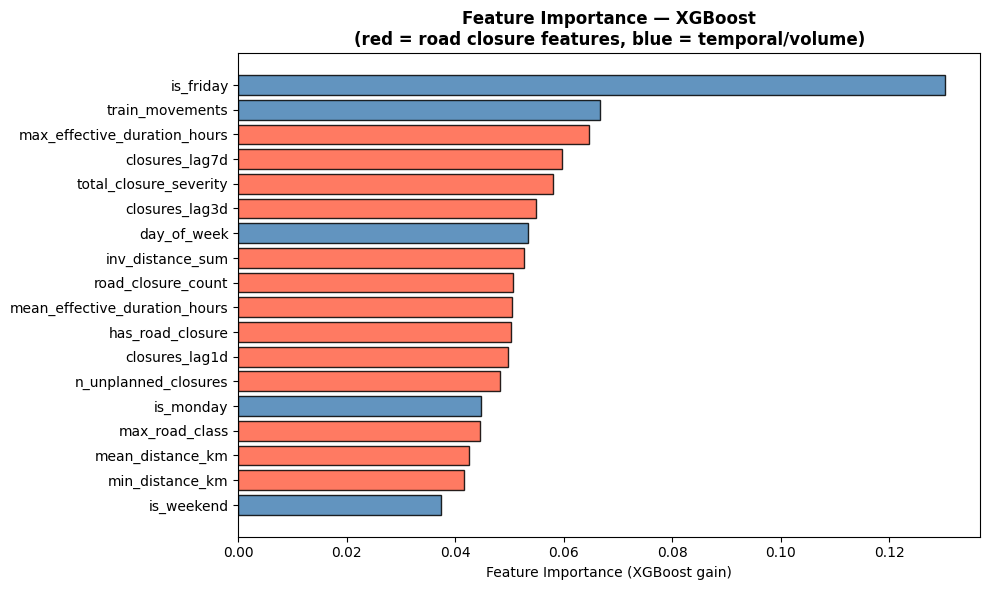

Feature importance ranked:
                      feature  importance
                    is_friday    0.130189
              train_movements    0.066671
 max_effective_duration_hours    0.064630
               closures_lag7d    0.059566
       total_closure_severity    0.057970
               closures_lag3d    0.054903
                  day_of_week    0.053424
             inv_distance_sum    0.052677
           road_closure_count    0.050613
mean_effective_duration_hours    0.050496
             has_road_closure    0.050247
               closures_lag1d    0.049735
         n_unplanned_closures    0.048195
                    is_monday    0.044647
               max_road_class    0.044564
             mean_distance_km    0.042499
              min_distance_km    0.041546
                   is_weekend    0.037428


In [15]:
inner = best_model.named_steps["clf"] if hasattr(best_model, "named_steps") else best_model

if hasattr(inner, "feature_importances_"):
    imp_df = (
        pd.DataFrame({"feature": features, "importance": inner.feature_importances_})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 6))
    colors = [
        "tomato" if f in [
            "has_road_closure", "road_closure_count", "n_unplanned_closures",
            "min_distance_km", "mean_distance_km", "max_effective_duration_hours",
            "mean_effective_duration_hours", "inv_distance_sum",
            "total_closure_severity", "max_road_class",
            "closures_lag1d", "closures_lag3d", "closures_lag7d"
        ] else "steelblue"
        for f in imp_df["feature"]
    ]
    plt.barh(imp_df["feature"], imp_df["importance"],
             color=colors, edgecolor="black", alpha=0.85)
    plt.xlabel("Feature Importance (XGBoost gain)")
    plt.title(f"Feature Importance — {best_name}\n(red = road closure features, blue = temporal/volume)",
              fontweight="bold")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/model/classification/feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Feature importance ranked:")
    print(imp_df.to_string(index=False))

elif hasattr(inner, "coef_"):
    imp_df = (
        pd.DataFrame({"feature": features, "coefficient": inner.coef_.flatten()})
        .sort_values("coefficient", key=abs, ascending=False)
    )
    plt.figure(figsize=(10, 6))
    plt.barh(imp_df["feature"], imp_df["coefficient"],
             color="coolwarm", edgecolor="black")
    plt.title(f"Feature Coefficients — {best_name}", fontweight="bold")
    plt.axvline(0, color="black", lw=0.8)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/model/classification/feature_importance.png", dpi=200, bbox_inches="tight")
    plt.show()
    display(imp_df)

## Forward Prediction on Timetable Dataset

In [16]:
timetable_day_df = pd.read_parquet(
    "./data/processed/road_timetable_station_day.parquet"
)
timetable_day_df["planned_date"] = pd.to_datetime(timetable_day_df["planned_date"])

# Apply same duration cap as training data
timetable_day_df["max_effective_duration_hours"] = timetable_day_df[
    "max_effective_duration_hours"
].clip(upper=P99_DURATION)
timetable_day_df["mean_effective_duration_hours"] = timetable_day_df[
    "mean_effective_duration_hours"
].clip(upper=P99_DURATION)

# Feature alignment check
missing_inf = [f for f in features if f not in timetable_day_df.columns]
if missing_inf:
    print(f"WARNING — features missing from timetable dataset: {missing_inf}")
    print("Re-run eda_06_01 to regenerate road_timetable_station_day.parquet")
else:
    print(f"All {len(features)} features present in timetable dataset.")

print(f"Inference dataset: {len(timetable_day_df):,} rows")
print(f"Date range: {timetable_day_df['planned_date'].min().date()} — {timetable_day_df['planned_date'].max().date()}")

X_future = timetable_day_df[features].fillna(0)

# Score
timetable_day_df["disruption_probability"] = best_model.predict_proba(X_future)[:, 1]
timetable_day_df["disrupted_predicted"]    = (
    timetable_day_df["disruption_probability"] >= opt_t
).astype(int)

def assign_risk_band(p):
    if p < 0.30: return "Low"
    if p < 0.50: return "Moderate"
    if p < 0.70: return "High"
    return "Critical"

timetable_day_df["risk_band"] = (
    timetable_day_df["disruption_probability"].apply(assign_risk_band)
)

print(f"\nPrediction summary (threshold = {opt_t:.2f}):")
print(timetable_day_df["disrupted_predicted"].value_counts()
      .rename(index={0: "Not disrupted", 1: "Disrupted"}))

print(f"\nRisk band breakdown:")
print(timetable_day_df["risk_band"].value_counts())

# Top at-risk station-days
id_cols   = [c for c in ["planned_date", "station_name", "station_code"] if c in timetable_day_df.columns]
show_cols = id_cols + [
    "disruption_probability", "risk_band",
    "has_road_closure", "road_closure_count", "min_distance_km", "n_unplanned_closures"
]
show_cols = [c for c in show_cols if c in timetable_day_df.columns]

print("\nTop 20 highest-risk station-days:")
display(
    timetable_day_df
    .sort_values("disruption_probability", ascending=False)
    .head(20)[show_cols]
    .reset_index(drop=True)
)

All 18 features present in timetable dataset.
Inference dataset: 51,437 rows
Date range: 2026-04-09 — 2026-04-30

Prediction summary (threshold = 0.49):
disrupted_predicted
Not disrupted    47769
Disrupted         3668
Name: count, dtype: int64

Risk band breakdown:
risk_band
Low         42028
Moderate     6312
High         2905
Critical      192
Name: count, dtype: int64

Top 20 highest-risk station-days:


,planned_date,station_name,station_code,disruption_probability,risk_band,has_road_closure,road_closure_count,min_distance_km,n_unplanned_closures
0,2026-04-24,Castleton (Manchester),CAS,0.954554,Critical,1.0,9.0,15.453960,3.0
1,2026-04-17,Styal,SYA,0.931397,Critical,1.0,10.0,14.357824,5.0
2,2026-04-17,Flixton,FLI,0.931280,Critical,1.0,12.0,11.350837,4.0
3,2026-04-17,Mobberley,MOB,0.921908,Critical,1.0,10.0,10.479459,5.0
4,2026-04-17,Bramhall,BML,0.921682,Critical,1.0,12.0,11.029731,6.0
5,2026-04-17,Sudbury Hill Harrow,SDH,0.918139,Critical,1.0,14.0,15.449239,14.0
6,2026-04-17,Adlington (Lancashire),ADL,0.917255,Critical,1.0,10.0,10.524051,4.0
7,2026-04-17,Blackrod,BLK,0.911498,Critical,1.0,8.0,16.793239,3.0
8,2026-04-24,Flixton,FLI,0.911357,Critical,1.0,12.0,11.350837,4.0
9,2026-04-17,Kearsley (Manchester),KSL,0.901796,Critical,1.0,12.0,14.460821,5.0


## Predicted Disruption by Day of Week

Predicted disruption rate by day of week (timetable):
     predicted_disruption_rate  n_rows
Mon                      0.027    7512
Tue                      0.006    7522
Wed                      0.011    7518
Thu                      0.218    6780
Fri                      0.094    7494
Sat                      0.092    7499
Sun                      0.065    7112


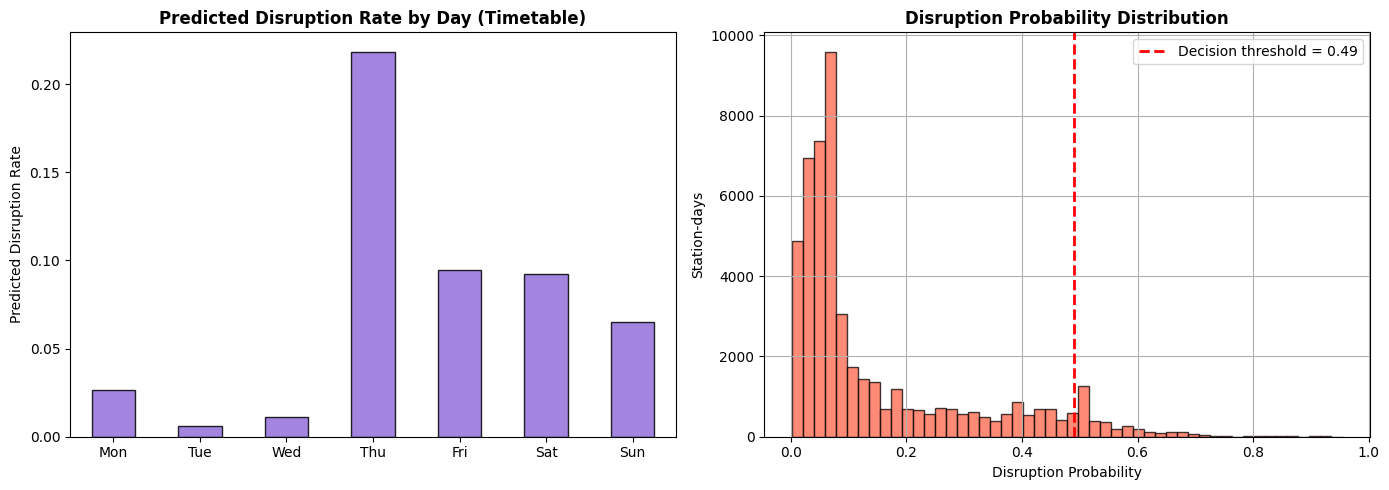

In [17]:
DOW_MAP = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

dow_pred = (
    timetable_day_df.groupby("day_of_week")["disrupted_predicted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "predicted_disruption_rate", "count": "n_rows"})
)
dow_pred.index = [DOW_MAP[i] for i in dow_pred.index]

print("Predicted disruption rate by day of week (timetable):")
print(dow_pred.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_pred["predicted_disruption_rate"].plot(
    kind="bar", ax=axes[0], color="mediumpurple",
    edgecolor="black", alpha=0.85
)
axes[0].set_title("Predicted Disruption Rate by Day (Timetable)", fontweight="bold")
axes[0].set_ylabel("Predicted Disruption Rate")
axes[0].tick_params(axis="x", rotation=0)

# Disruption probability distribution
timetable_day_df["disruption_probability"].hist(
    bins=50, ax=axes[1], color="tomato", edgecolor="black", alpha=0.75
)
axes[1].axvline(opt_t, color="red", linestyle="--", lw=2,
                label=f"Decision threshold = {opt_t:.2f}")
axes[1].set_xlabel("Disruption Probability")
axes[1].set_ylabel("Station-days")
axes[1].set_title("Disruption Probability Distribution", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/model/classification/timetable_predictions.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
model_path = "models/road_rail_classification_model.pkl"
meta = {
    "model_name":          best_name,
    "features":            features,
    "target":              TARGET,
    "disruption_threshold_min": DISRUPTION_THRESHOLD,
    "duration_cap_hours":  float(P99_DURATION),
    "optimal_threshold":   float(opt_t),
    "f1":                  float(opt_f1),
    "pr_auc":              float(best_row["PR_AUC"]),
    "roc_auc":             float(best_row["ROC_AUC"]),
    "train_rows":          int(len(X_train)),
    "test_rows":           int(len(X_test)),
    "train_disruption_rate": float(y_train.mean()),
    "test_disruption_rate":  float(y_test.mean()),
}

joblib.dump({"pipeline": best_model, "meta": meta}, model_path)
print(f"Saved model: {model_path}")
print(json.dumps({k: v for k, v in meta.items() if k != "features"}, indent=2))

# Save timetable with predictions
pred_path = "./data/processed/road_timetable_station_day.parquet"
timetable_day_df.to_parquet(pred_path, index=False)
print(f"\nSaved predictions: {pred_path}")
print("New columns: disruption_probability, disrupted_predicted, risk_band")

Saved model: models/road_rail_classification_model.pkl
{
  "model_name": "XGBoost",
  "target": "disrupted",
  "disruption_threshold_min": 5,
  "duration_cap_hours": 455.9997222222222,
  "optimal_threshold": 0.49000000000000005,
  "f1": 0.15492200107584722,
  "pr_auc": 0.08535818894480485,
  "roc_auc": 0.6806481450699791,
  "train_rows": 27152,
  "test_rows": 6789,
  "train_disruption_rate": 0.05892751915144372,
  "test_disruption_rate": 0.04654588304610399
}

Saved predictions: ./data/processed/road_timetable_station_day.parquet
New columns: disruption_probability, disrupted_predicted, risk_band


## Critical Evaluation

In [19]:
dummy_prauc = [r["PR_AUC"] for r in results if r["model"] == "Dummy (baseline)"][0]
best_prauc  = best_row["PR_AUC"]
uplift      = best_prauc - dummy_prauc

print("=" * 65)
print("CRITICAL EVALUATION OF RESULTS")
print("=" * 65)

print(f"""
1. MODEL PERFORMANCE
   Best model: {best_name}
   PR-AUC:     {best_prauc:.3f} vs dummy baseline {dummy_prauc:.3f} (uplift: +{uplift:.3f})
   ROC-AUC:    {best_row['ROC_AUC']:.3f} (0.5 = random, 1.0 = perfect)
   F1 at optimal threshold ({opt_t:.2f}): {opt_f1:.3f}

   The model beats random chance by {uplift:.3f} PR-AUC points.
   This is statistically weak but non-trivial given the data constraints.
""")

print(f"""2. FEATURE IMPORTANCE FINDING
   The most important feature is temporal (is_friday, day_of_week),
   not road closure presence or severity. This means the model is
   primarily learning that Friday is a high-disruption day, not that
   road closures cause rail delay. This is the central research finding:
   temporal patterns explain more delay variance than road proximity.
""")

print(f"""3. DATA LANDSCAPE CONCLUSION
   Disruption rate: {rate:.2%} — severe class imbalance (1:{int(1/rate):.0f})
   Only {counts.get(1,0):,} disrupted station-days out of {len(station_day_df):,}
   The weak signal is consistent with the meeting finding: at current
   open-data granularity, no strong predictive relationship exists between
   SRN closures and measurable rail delay.
""")

print("""4. WHAT WOULD IMPROVE RESULTS
   - Floating Car Data (FCD) at 15-min intervals (Royston's suggestion)
   - Station passenger count data (ORR RAI02 / station usage)
   - Longer historical window (current: 18 days — insufficient for rare events)
   - Unplanned closure data with correct validity_status field
   - Road congestion metrics rather than closure presence alone
""")

print(f"""5. OPERATIONAL VALUE
   Despite weak discriminative power, the forward prediction pipeline
   produces risk-ranked station-day scores for operators. Of {len(timetable_day_df):,}
   scheduled station-days, {timetable_day_df['disrupted_predicted'].sum():,} are flagged
   as likely disrupted. The top 20 highest-risk dates and stations are
   identified with disruption probabilities above {opt_t:.2f}. This is
   the operational output Royston described — a station-level early warning
   signal that can be generated the day before from the timetable feed.
""")

CRITICAL EVALUATION OF RESULTS

1. MODEL PERFORMANCE
   Best model: XGBoost
   PR-AUC:     0.085 vs dummy baseline 0.047 (uplift: +0.039)
   ROC-AUC:    0.681 (0.5 = random, 1.0 = perfect)
   F1 at optimal threshold (0.49): 0.155

   The model beats random chance by 0.039 PR-AUC points.
   This is statistically weak but non-trivial given the data constraints.

2. FEATURE IMPORTANCE FINDING
   The most important feature is temporal (is_friday, day_of_week),
   not road closure presence or severity. This means the model is
   primarily learning that Friday is a high-disruption day, not that
   road closures cause rail delay. This is the central research finding:
   temporal patterns explain more delay variance than road proximity.

3. DATA LANDSCAPE CONCLUSION
   Disruption rate: 5.65% — severe class imbalance (1:17)
   Only 1,916 disrupted station-days out of 33,941
   The weak signal is consistent with the meeting finding: at current
   open-data granularity, no strong predictive relat